## Imports

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import json
import os 
from datetime import datetime 
from pathlib import Path

## Ingestão

In [2]:
df_incidents = pd.read_csv('data/incidents_master.csv')
df_market = pd.read_csv('data/market_impact.csv')
df_financials = pd.read_csv('data/financial_impact.csv')

In [3]:
df_incidents.head()

,incident_id,company_name,company_revenue_usd,country_hq,industry_primary,industry_secondary,employee_count,is_public_company,stock_ticker,incident_date,...,data_source_primary,data_source_secondary,data_source_type,confidence_tier,quality_score,quality_grade,review_flag,notes,created_at,updated_at
0,2021-0508-001,Quantum Asset Assurance Group Inc.,1.343769e+09,US,52,54,3940,True,QAA,2021-05-08,...,https://www.sec.gov/cgi-bin/browse-edgar?actio...,https://www.quantum-asset-assurance-g.com/news...,sec_filing,1,97.89,Gold,NaN,Multiple subsidiaries affected across 6 jurisd...,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,Quantum Apex Ventures Ltd.,6.367059e+07,GB,51,NaN,250,False,NaN,2025-12-11,...,https://www.theregister.com/2025/06/14/quantum...,https://blog.talosintelligence.com/2025/09/qua...,verified_media,3,86.74,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,BitWire Innovations Corp.,2.480619e+10,US,51,NaN,71369,True,BITW,2023-01-15,...,https://therecord.media/2023/12/10/bitwire-inn...,https://blog.talosintelligence.com/2023/08/bit...,verified_media,4,83.74,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,Sterling Forge Markets Holdings Inc.,1.398259e+08,US,44-45,NaN,912,True,SFM,2021-03-15,...,https://www.sterling-forge-markets-ho.com/news...,https://www.mandiant.com/resources/blog/sterli...,company_pr,2,94.51,Gold,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,Sierra Quantum Innovations Group Inc.,6.916977e+08,US,51,NaN,1662,True,SQI,2021-12-04,...,https://www.sierra-quantum-innovation.com/news...,NaN,company_pr,2,79.82,Silver,NaN,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [4]:
df_financials.head()

,incident_id,direct_loss_usd,direct_loss_method,ransom_demanded_usd,ransom_paid_usd,ransom_source,recovery_cost_usd,legal_fees_usd,regulatory_fine_usd,insurance_payout_usd,total_loss_usd,total_loss_method,total_loss_lower_bound,total_loss_upper_bound,inflation_adjusted_usd,cpi_index_used,notes,created_at,updated_at
0,2021-0508-001,12600000.00,disclosed,13802654.69,NaN,NaN,9455354.49,2496545.93,90695.25,6756288.97,24642595.67,calculated,15348190.29,4.374658e+07,29237902.75,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2025-1211-001,7640471.18,disclosed,NaN,NaN,NaN,5857150.47,1809188.41,NaN,2691027.33,15306810.06,disclosed,10206030.81,1.890634e+07,15306810.06,CPI-U 2025 (321.5),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2023-0115-001,34881599.59,calculated,NaN,NaN,NaN,26404111.95,10330703.43,NaN,31759649.99,71616414.97,disclosed,60854299.98,1.051520e+08,75564575.92,CPI-U 2023 (304.702),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0315-001,4682151.47,disclosed,NaN,NaN,NaN,3642946.48,1029035.85,NaN,1772460.33,9354133.80,disclosed,7648967.81,1.452521e+07,11098475.91,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2021-1204-001,2684607.92,estimated,NaN,NaN,NaN,2574871.33,206822.23,NaN,NaN,5466301.48,estimated,3519806.28,6.755823e+06,6485647.58,CPI-U 2021 (270.97),NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [5]:
df_market.head()

,incident_id,stock_ticker,price_7d_before,price_disclosure_day,price_1d_after,price_7d_after,price_30d_after,volume_avg_30d_baseline,volume_disclosure_day,sector_index,...,p_value_30d,earnings_announcement_within_7d,market_cap_at_disclosure,volume_ratio_disclosure,pre_incident_volatility_30d,post_incident_volatility_30d,days_to_price_recovery,notes,created_at,updated_at
0,2023-0115-001,BITW,262.07,251.95,245.11,250.34,246.87,19782288,48767234,S&P 500 Information Technology,...,1.00000,True,1.181988e+11,2.4652,0.027705,0.052161,255.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
1,2021-0315-001,SFM,9.37,9.09,8.73,8.78,8.67,458826,1421143,S&P 500 Consumer Discretionary,...,0.98240,False,6.489114e+08,3.0973,0.017116,0.027638,324.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
2,2021-1204-001,SQI,14.60,13.36,13.09,13.28,13.17,230932,354433,S&P 500 Information Technology,...,1.00000,False,4.735164e+09,1.5348,0.038209,0.045756,19.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
3,2021-0213-001,STUT.DE,5.34,5.43,5.27,5.36,5.37,2521343,6491913,S&P 500 Consumer Discretionary,...,1.00000,False,2.984412e+09,2.5748,0.027980,0.030972,24.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z
4,2025-0529-001,BAZA,465.19,441.08,410.45,428.36,429.49,1235984,3250371,S&P 500 Consumer Discretionary,...,0.38875,False,2.194296e+11,2.6298,0.025212,0.038232,313.0,NaN,2026-02-12T10:00:00Z,2026-02-12T10:00:00Z


In [6]:
print(df_incidents.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   incident_id               850 non-null    object 
 1   company_name              850 non-null    object 
 2   company_revenue_usd       850 non-null    float64
 3   country_hq                850 non-null    object 
 4   industry_primary          850 non-null    object 
 5   industry_secondary        153 non-null    object 
 6   employee_count            850 non-null    int64  
 7   is_public_company         850 non-null    bool   
 8   stock_ticker              412 non-null    object 
 9   incident_date             850 non-null    object 
 10  incident_date_estimated   850 non-null    bool   
 11  discovery_date            850 non-null    object 
 12  disclosure_date           850 non-null    object 
 13  attack_vector_primary     850 non-null    object 
 14  attack_vec

In [7]:
print(df_market.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 31 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   incident_id                      358 non-null    object 
 1   stock_ticker                     358 non-null    object 
 2   price_7d_before                  358 non-null    float64
 3   price_disclosure_day             358 non-null    float64
 4   price_1d_after                   358 non-null    float64
 5   price_7d_after                   358 non-null    float64
 6   price_30d_after                  358 non-null    float64
 7   volume_avg_30d_baseline          358 non-null    int64  
 8   volume_disclosure_day            358 non-null    int64  
 9   sector_index                     358 non-null    object 
 10  sector_return_same_period        358 non-null    float64
 11  abnormal_return_1d               358 non-null    float64
 12  abnormal_return_7d    

In [8]:
print(df_financials.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   incident_id             778 non-null    object 
 1   direct_loss_usd         778 non-null    float64
 2   direct_loss_method      778 non-null    object 
 3   ransom_demanded_usd     206 non-null    float64
 4   ransom_paid_usd         86 non-null     float64
 5   ransom_source           86 non-null     object 
 6   recovery_cost_usd       778 non-null    float64
 7   legal_fees_usd          778 non-null    float64
 8   regulatory_fine_usd     132 non-null    float64
 9   insurance_payout_usd    435 non-null    float64
 10  total_loss_usd          778 non-null    float64
 11  total_loss_method       778 non-null    object 
 12  total_loss_lower_bound  778 non-null    float64
 13  total_loss_upper_bound  778 non-null    float64
 14  inflation_adjusted_usd  778 non-null    fl

In [9]:
print(df_incidents.isna().sum())

incident_id                   0
company_name                  0
company_revenue_usd           0
country_hq                    0
industry_primary              0
industry_secondary          697
employee_count                0
is_public_company             0
stock_ticker                438
incident_date                 0
incident_date_estimated       0
discovery_date                0
disclosure_date               0
attack_vector_primary         0
attack_vector_secondary     639
attack_chain                275
attributed_group            368
attribution_confidence      368
data_compromised_records    248
data_type                   248
systems_affected              0
downtime_hours              430
data_source_primary           0
data_source_secondary       464
data_source_type              0
confidence_tier               0
quality_score                 0
quality_grade                 0
review_flag                 780
notes                       636
created_at                    0
updated_

In [10]:
print(df_market.isna().sum())

incident_id                          0
stock_ticker                         0
price_7d_before                      0
price_disclosure_day                 0
price_1d_after                       0
price_7d_after                       0
price_30d_after                      0
volume_avg_30d_baseline              0
volume_disclosure_day                0
sector_index                         0
sector_return_same_period            0
abnormal_return_1d                   0
abnormal_return_7d                   0
abnormal_return_30d                  0
car_neg1_to_pos1                     0
car_0_to_7                           0
car_0_to_30                          0
car_0_to_90                          0
t_statistic_1d                       0
p_value_1d                           0
t_statistic_30d                      0
p_value_30d                          0
earnings_announcement_within_7d      0
market_cap_at_disclosure             0
volume_ratio_disclosure              0
pre_incident_volatility_3

In [11]:
print(df_financials.isna().sum())

incident_id                 0
direct_loss_usd             0
direct_loss_method          0
ransom_demanded_usd       572
ransom_paid_usd           692
ransom_source             692
recovery_cost_usd           0
legal_fees_usd              0
regulatory_fine_usd       646
insurance_payout_usd      343
total_loss_usd              0
total_loss_method           0
total_loss_lower_bound      0
total_loss_upper_bound      0
inflation_adjusted_usd      0
cpi_index_used              0
notes                     530
created_at                  0
updated_at                  0
dtype: int64


### metadados de ingestão

In [12]:
df_incidents['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')
df_market['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')
df_financials['_ingestion_timestamp'] = datetime.now().strftime('%Y-%m-%d')

## Conversão de tipos

In [13]:
# Datas
for col in ['incident_date', 'discovery_date', 'disclosure_date', '_ingestion_timestamp']:
    df_incidents[col] = pd.to_datetime(df_incidents[col], errors='coerce')

df_market['_ingestion_timestamp'] = pd.to_datetime(df_market['_ingestion_timestamp'], errors='coerce')

df_financials['_ingestion_timestamp'] = pd.to_datetime(df_financials['_ingestion_timestamp'], errors='coerce')

# created_at e updated_at têm fuso
df_incidents['created_at'] = pd.to_datetime(df_incidents['created_at'], utc=True, errors='coerce')
df_incidents['updated_at']  = pd.to_datetime(df_incidents['updated_at'],  utc=True, errors='coerce')

df_market['created_at'] = pd.to_datetime(df_market['created_at'], utc=True, errors='coerce')
df_market['updated_at']  = pd.to_datetime(df_market['updated_at'],  utc=True, errors='coerce')

df_financials['created_at'] = pd.to_datetime(df_financials['created_at'], utc=True, errors='coerce')
df_financials['updated_at']  = pd.to_datetime(df_financials['updated_at'],  utc=True, errors='coerce')

In [14]:
df_incidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   incident_id               850 non-null    object             
 1   company_name              850 non-null    object             
 2   company_revenue_usd       850 non-null    float64            
 3   country_hq                850 non-null    object             
 4   industry_primary          850 non-null    object             
 5   industry_secondary        153 non-null    object             
 6   employee_count            850 non-null    int64              
 7   is_public_company         850 non-null    bool               
 8   stock_ticker              412 non-null    object             
 9   incident_date             850 non-null    datetime64[ns]     
 10  incident_date_estimated   850 non-null    bool               
 11  discovery_date     

In [15]:
df_market.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 32 columns):
 #   Column                           Non-Null Count  Dtype              
---  ------                           --------------  -----              
 0   incident_id                      358 non-null    object             
 1   stock_ticker                     358 non-null    object             
 2   price_7d_before                  358 non-null    float64            
 3   price_disclosure_day             358 non-null    float64            
 4   price_1d_after                   358 non-null    float64            
 5   price_7d_after                   358 non-null    float64            
 6   price_30d_after                  358 non-null    float64            
 7   volume_avg_30d_baseline          358 non-null    int64              
 8   volume_disclosure_day            358 non-null    int64              
 9   sector_index                     358 non-null    object             
 10  se

In [16]:
df_financials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 778 entries, 0 to 777
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   incident_id             778 non-null    object             
 1   direct_loss_usd         778 non-null    float64            
 2   direct_loss_method      778 non-null    object             
 3   ransom_demanded_usd     206 non-null    float64            
 4   ransom_paid_usd         86 non-null     float64            
 5   ransom_source           86 non-null     object             
 6   recovery_cost_usd       778 non-null    float64            
 7   legal_fees_usd          778 non-null    float64            
 8   regulatory_fine_usd     132 non-null    float64            
 9   insurance_payout_usd    435 non-null    float64            
 10  total_loss_usd          778 non-null    float64            
 11  total_loss_method       778 non-null    objec

## Persistência

In [17]:
Path('data/bronze').mkdir(parents=True, exist_ok=True)

df_incidents.to_parquet('./data/bronze/bronze_incidents.parquet')
df_market.to_parquet('./data/bronze/bronze_market.parquet')
df_financials.to_parquet('./data/bronze/bronze_financials.parquet')

In [18]:
#tamanho dataset original em bits
print('Tamanho do dataset  incidents original em bits: ' + str(Path('data/incidents_master.csv').stat().st_size))
print('Tamanho do dataset  market original em bits: ' + str(Path('data/market_impact.csv').stat().st_size))
print('Tamanho do dataset  financials original em bits: ' + str(Path('data/financial_impact.csv').stat().st_size))
print('---------------------------------------------------------')
print('Tamanho do bronze_incidents em bits: ' + str(Path('data/bronze/bronze_incidents.parquet').stat().st_size))
print('Tamanho do bronze_financials em bits: ' + str(Path('data/bronze/bronze_financials.parquet').stat().st_size))
print('Tamanho do bronze_market em bits: ' + str(Path('data/bronze/bronze_market.parquet').stat().st_size))

Tamanho do dataset  incidents original em bits: 438941
Tamanho do dataset  market original em bits: 109318
Tamanho do dataset  financials original em bits: 170578
---------------------------------------------------------
Tamanho do bronze_incidents em bits: 132912
Tamanho do bronze_financials em bits: 74898
Tamanho do bronze_market em bits: 92005


In [19]:
df_bronze_incidents = pd.read_parquet('./data/bronze/bronze_incidents.parquet')
df_bronze_market = pd.read_parquet('./data/bronze/bronze_market.parquet')
df_bronze_financials = pd.read_parquet('./data/bronze/bronze_financials.parquet')

### Verificando nulos

In [53]:
def print_nulos(df):
    missing=pd.DataFrame(df.isnull().sum(),columns=["Null Values"])
    missing["% Missing Values"]=(df.isna().sum()/len(df)*100)
    missing = missing[missing["% Missing Values"] > 0].sort_values(by="% Missing Values", ascending=False)
    print(missing.head(100))

In [54]:
print('bronze_incidents')
print_nulos(df_bronze_incidents)

print('\n--------\nbronze_market')
print_nulos(df_bronze_market)

print('\n--------\nbronze_financials')
print_nulos(df_bronze_financials)


bronze_incidents
                          Null Values  % Missing Values
review_flag                       780         91.764706
industry_secondary                697         82.000000
attack_vector_secondary           639         75.176471
notes                             636         74.823529
data_source_secondary             464         54.588235
stock_ticker                      438         51.529412
downtime_hours                    430         50.588235
attribution_confidence            368         43.294118
attributed_group                  368         43.294118
attack_chain                      275         32.352941
data_type                         248         29.176471
data_compromised_records          248         29.176471

--------
bronze_market
                        Null Values  % Missing Values
notes                           266         74.301676
days_to_price_recovery           36         10.055866

--------
bronze_financials
                      Null Values  % Miss

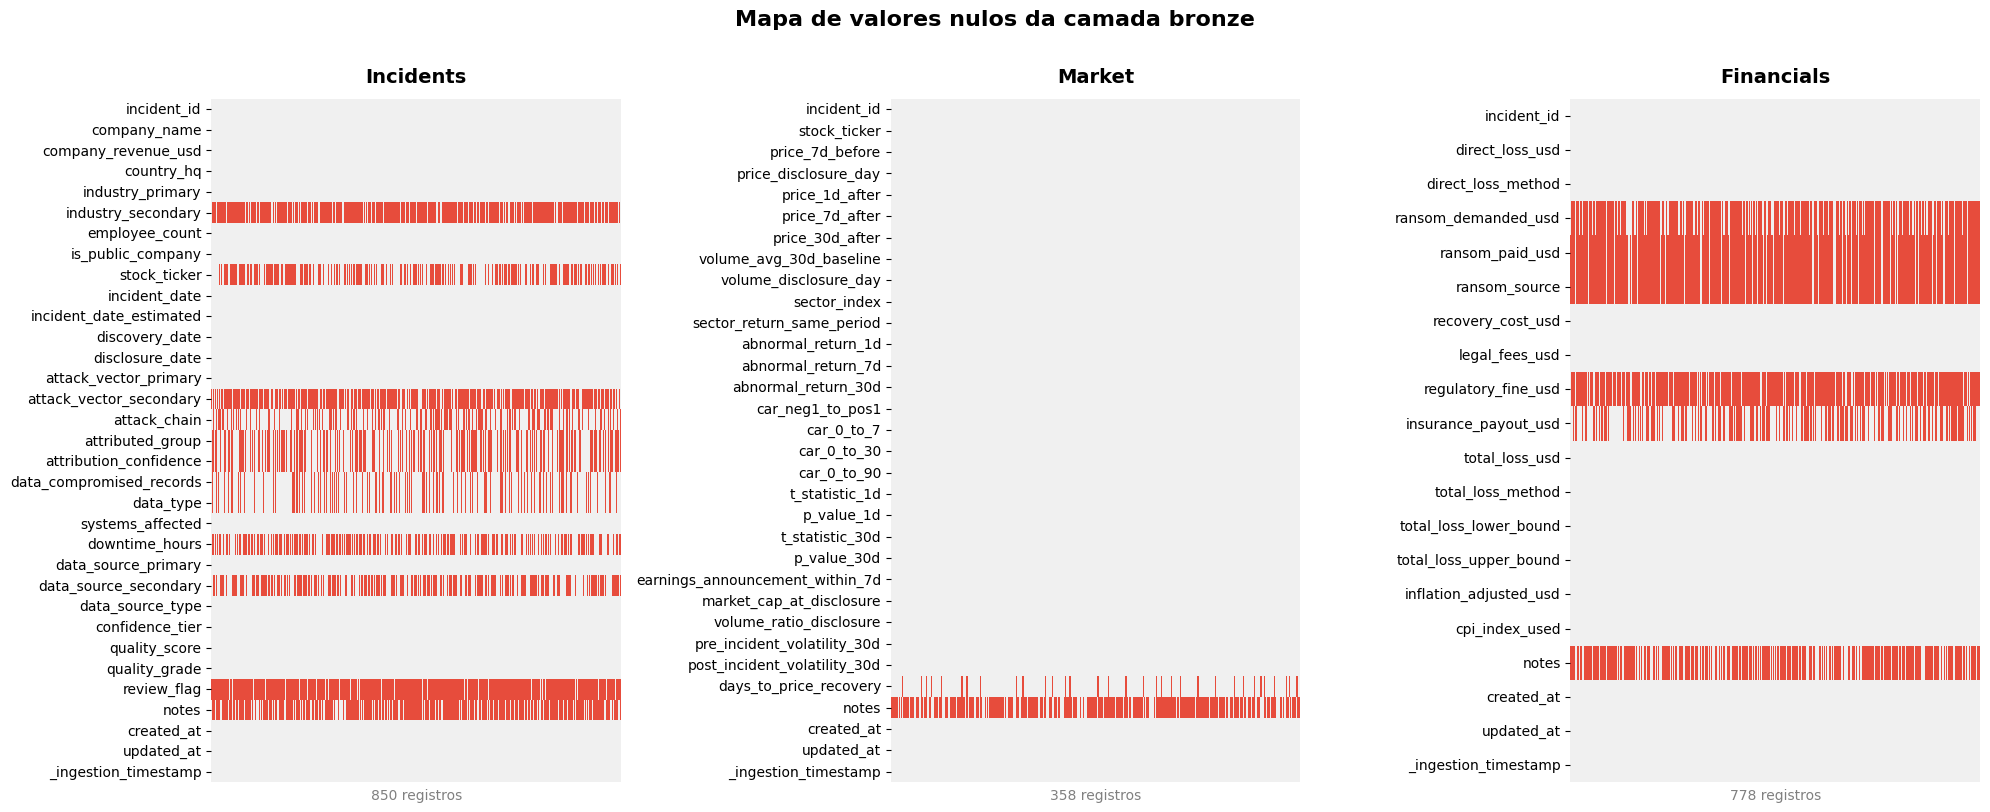

In [67]:
# Visualizacao do mapa de nulos
fig, axes = plt.subplots(1, 3, figsize=(20,8))

datasets = {
    "Incidents": df_bronze_incidents,
    "Market": df_bronze_market,
    "Financials": df_bronze_financials,
}

for ax, (title, df) in zip(axes, datasets.items()):
    sns.heatmap(
        df.isnull().T,
        cmap=['#F0F0F0','#E74C3C'],
        cbar=False, 
        ax=ax, 
        xticklabels=False, 
        yticklabels=True
    )
    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel(f"{len(df):,} registros", fontsize=10, color="gray")
    ax.set_ylabel("")

fig.suptitle("Mapa de valores nulos da camada bronze", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Buscando duplicatas

In [71]:
datasets = [df_bronze_incidents, df_bronze_market, df_bronze_financials]

for df in datasets:
    print(df[df.duplicated()])

Empty DataFrame
Columns: [incident_id, company_name, company_revenue_usd, country_hq, industry_primary, industry_secondary, employee_count, is_public_company, stock_ticker, incident_date, incident_date_estimated, discovery_date, disclosure_date, attack_vector_primary, attack_vector_secondary, attack_chain, attributed_group, attribution_confidence, data_compromised_records, data_type, systems_affected, downtime_hours, data_source_primary, data_source_secondary, data_source_type, confidence_tier, quality_score, quality_grade, review_flag, notes, created_at, updated_at, _ingestion_timestamp]
Index: []

[0 rows x 33 columns]
Empty DataFrame
Columns: [incident_id, stock_ticker, price_7d_before, price_disclosure_day, price_1d_after, price_7d_after, price_30d_after, volume_avg_30d_baseline, volume_disclosure_day, sector_index, sector_return_same_period, abnormal_return_1d, abnormal_return_7d, abnormal_return_30d, car_neg1_to_pos1, car_0_to_7, car_0_to_30, car_0_to_90, t_statistic_1d, p_value_

In [ ]:
datasets = [df_bronze_incidents, df_bronze_market, df_bronze_financials]

for df in datasets:
    print(df[df.duplicated(subset=['incident_id'])])


Empty DataFrame
Columns: [incident_id, company_name, company_revenue_usd, country_hq, industry_primary, industry_secondary, employee_count, is_public_company, stock_ticker, incident_date, incident_date_estimated, discovery_date, disclosure_date, attack_vector_primary, attack_vector_secondary, attack_chain, attributed_group, attribution_confidence, data_compromised_records, data_type, systems_affected, downtime_hours, data_source_primary, data_source_secondary, data_source_type, confidence_tier, quality_score, quality_grade, review_flag, notes, created_at, updated_at, _ingestion_timestamp]
Index: []

[0 rows x 33 columns]
Empty DataFrame
Columns: [incident_id, stock_ticker, price_7d_before, price_disclosure_day, price_1d_after, price_7d_after, price_30d_after, volume_avg_30d_baseline, volume_disclosure_day, sector_index, sector_return_same_period, abnormal_return_1d, abnormal_return_7d, abnormal_return_30d, car_neg1_to_pos1, car_0_to_7, car_0_to_30, car_0_to_90, t_statistic_1d, p_value_

## Metadados de Ingestão — Bronze

Registro completo de metadados conforme exigido no projeto: nome do arquivo, quantidade de linhas, hash SHA-256 e data/hora da carga.

In [87]:
import hashlib
from datetime import datetime
from pathlib import Path

lista_metadados = []

for item in ['data/incidents_master.csv', 'data/market_impact.csv', 'data/financial_impact.csv']:

    arquivo = Path(item)

    # Hash SHA-256 do arquivo original
    sha256 = hashlib.sha256(arquivo.read_bytes()).hexdigest()

    metadata_bronze = {
        'arquivo': arquivo.name,
        'linhas': len(df),
        'colunas': len(df.columns),
        'tamanho_bytes': arquivo.stat().st_size,
        'hash_sha256': sha256,
        'data_carga': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'camada': 'bronze'
    }

    lista_metadados.append(metadata_bronze)

    print(json.dumps(metadata_bronze, indent=2))

# Salvar metadados em JSON ao lado do parquet
Path('data/bronze').mkdir(parents=True, exist_ok=True)
with open('data/bronze/metadata_bronze.json', 'w') as f:
    json.dump(lista_metadados, f, indent=2)

print('\nMetadados salvos em data/bronze/metadata_bronze.json')


{
  "arquivo": "incidents_master.csv",
  "linhas": 778,
  "colunas": 20,
  "tamanho_bytes": 438941,
  "hash_sha256": "9819d9ad6baeadca4c503d1146def6504da32e42b9e14e38b0008b24ffc84225",
  "data_carga": "2026-04-08 13:19:39",
  "camada": "bronze"
}
{
  "arquivo": "market_impact.csv",
  "linhas": 778,
  "colunas": 20,
  "tamanho_bytes": 109318,
  "hash_sha256": "d7f4ef0645bbc50f9e4cd159800f1f3f69f87fb5a9d0489f987f1ebc0fb827c1",
  "data_carga": "2026-04-08 13:19:39",
  "camada": "bronze"
}
{
  "arquivo": "financial_impact.csv",
  "linhas": 778,
  "colunas": 20,
  "tamanho_bytes": 170578,
  "hash_sha256": "9e375eb6f35b70d40166ae03e62cfe809d3e976bb9951498e6f5f2ce78b46679",
  "data_carga": "2026-04-08 13:19:39",
  "camada": "bronze"
}

Metadados salvos em data/bronze/metadata_bronze.json


## Relatório de Qualidade dos Dados — Bronze

Verificação automática com regras claras para identificar falhas de qualidade.

In [78]:
def gerar_relatorio_qualidade(df, nome_camada='bronze'):
    relatorio = []
    total_linhas = len(df)

    for col in df.columns:
        nulos = df[col].isnull().sum()
        pct_nulo = nulos / total_linhas * 100
        duplicados = df[col].duplicated().sum() if df[col].dtype == 'object' else None
        status = 'OK'
        if pct_nulo > 50:
            status = 'CRITICO - >50% nulos'
        elif pct_nulo > 20:
            status = 'ATENCAO - >20% nulos'
        relatorio.append({
            'coluna': col,
            'tipo': str(df[col].dtype),
            'nulos': nulos,
            'pct_nulo': round(pct_nulo, 2),
            'status': status
        })

    df_rel = pd.DataFrame(relatorio)
    duplicatas_totais = df.duplicated().sum()
    print(f'=== Relatório de Qualidade — Camada {nome_camada.upper()} ===')
    print(f'Total de linhas : {total_linhas}')
    print(f'Linhas duplicadas: {duplicatas_totais}')
    print()
    print(df_rel[['coluna','tipo','nulos','pct_nulo','status']].to_string(index=False))
    return df_rel

df_qualidade_incidents = gerar_relatorio_qualidade(df_bronze_incidents, 'bronze')
df_qualidade_market = gerar_relatorio_qualidade(df_bronze_market, 'bronze')
df_qualidade_financials = gerar_relatorio_qualidade(df_bronze_financials, 'bronze')

# Salvar relatórios como CSV
df_qualidade_incidents.to_csv('data/bronze/relatorio_qualidade_bronze_incidents.csv', index=False)
df_qualidade_market.to_csv('data/bronze/relatorio_qualidade_bronze_market.csv', index=False)
df_qualidade_financials.to_csv('data/bronze/relatorio_qualidade_bronze_financials.csv', index=False)


=== Relatório de Qualidade — Camada BRONZE ===
Total de linhas : 850
Linhas duplicadas: 0

                  coluna                tipo  nulos  pct_nulo               status
             incident_id              object      0      0.00                   OK
            company_name              object      0      0.00                   OK
     company_revenue_usd             float64      0      0.00                   OK
              country_hq              object      0      0.00                   OK
        industry_primary              object      0      0.00                   OK
      industry_secondary              object    697     82.00 CRITICO - >50% nulos
          employee_count               int64      0      0.00                   OK
       is_public_company                bool      0      0.00                   OK
            stock_ticker              object    438     51.53 CRITICO - >50% nulos
           incident_date      datetime64[ns]      0      0.00                  

# Silver

In [ ]:
df_silver = df_bronze.copy()

### Ingestão 

# Limpeza, Tratamento de Datas e Padronização

### Removendo linhas totalmente duplicadas

In [ ]:
df_silver = df_silver.drop_duplicates()

### Padronizando colunas categóricas

In [ ]:
colunas_categoricas = ['attack_vector_primary', 'attack_vector_secondary', 'country_hq', 'data_type', 'attribution_confidence']
for col in colunas_categoricas:
    df_silver[col] = df_silver[col].str.lower().str.strip()

### Preenchendo valores vazios em colunas secundárias de ataque e grupo com 'desconhecido'

In [ ]:
df_silver['attack_vector_secondary'] = df_silver['attack_vector_secondary'].fillna('desconhecido')
df_silver['attributed_group'] = df_silver['attributed_group'].fillna('desconhecido')
df_silver['stock_ticker'] = df_silver['stock_ticker'].fillna('nao_capital_aberto')

### Preenchendo nulos em colunas numéricas com 0 (ex: empresas que não tiveram horas de inatividade)

In [ ]:
df_silver['downtime_hours'] = df_silver['downtime_hours'].fillna(0)
df_silver['data_compromised_records'] = df_silver['data_compromised_records'].fillna(0)

### Remoção de colunas com risco de Data Leakage


In [ ]:
colunas_leakage = ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag']

df_silver = df_silver.drop(columns=colunas_leakage)

print(f"Colunas removidas: {colunas_leakage}")
print(f"Shape após remoção: {df_silver.shape}")

Colunas removidas: ['quality_score', 'quality_grade', 'confidence_tier', 'review_flag']
Shape após remoção: (850, 29)


### Criação do Label para Machine Learning


In [ ]:
df_silver['_is_high_impact'] = (
    (df_silver['data_compromised_records'] > 100_000) |
    (df_silver['downtime_hours'] > 72)
).astype(int)

print("Distribuição do label:")
print(df_silver['_is_high_impact'].value_counts())
print(f"\nProporção de alto impacto: {df_silver['_is_high_impact'].mean():.2%}")

Distribuição do label:
_is_high_impact
0    479
1    371
Name: count, dtype: int64

Proporção de alto impacto: 43.65%


### Salvando a Camada Silver


In [ ]:
Path('data/silver').mkdir(parents=True, exist_ok=True)
df_silver.to_parquet('./data/silver/silver.parquet', index=False)

print(f"Silver salvo com sucesso!")
print(f"Shape final: {df_silver.shape}")
print(f"Tamanho do arquivo: {Path('data/silver/silver.parquet').stat().st_size} bytes")

Silver salvo com sucesso!
Shape final: (850, 30)
Tamanho do arquivo: 126994 bytes


## Documentação das Transformações — Silver

Registro de todas as transformações aplicadas sobre a camada Bronze para rastreabilidade.

In [ ]:
transformacoes = [
    {'etapa': '1', 'acao': 'Remocao de duplicatas',         'detalhes': 'drop_duplicates() — linhas 100% identicas removidas'},
    {'etapa': '2', 'acao': 'Conversao de tipos de data',    'detalhes': 'incident_date, discovery_date, disclosure_date, created_at, updated_at -> datetime'},
    {'etapa': '3', 'acao': 'Padronizacao de categorias',    'detalhes': 'lower().strip() em: attack_vector_primary/secondary, country_hq, data_type, attribution_confidence'},
    {'etapa': '4', 'acao': 'Preenchimento de nulos',        'detalhes': 'attack_vector_secondary, attributed_group -> desconhecido; stock_ticker -> nao_capital_aberto; downtime_hours, data_compromised_records -> 0'},
    {'etapa': '5', 'acao': 'Remocao anti-leakage',          'detalhes': 'Removidas: quality_score, quality_grade, confidence_tier, review_flag'},
    {'etapa': '6', 'acao': 'Criacao do label ML',           'detalhes': 'is_high_impact=1 se data_compromised_records>100k OU downtime_hours>72'},
]

df_trans = pd.DataFrame(transformacoes)
print(df_trans.to_string(index=False))

# Salvar documentacao
df_trans.to_csv('data/silver/documentacao_transformacoes.csv', index=False)
print('\nDocumentacao salva em data/silver/documentacao_transformacoes.csv')


etapa                       acao                                                                                                                                     detalhes
    1      Remocao de duplicatas                                                                                          drop_duplicates() — linhas 100% identicas removidas
    2 Conversao de tipos de data                                                           incident_date, discovery_date, disclosure_date, created_at, updated_at -> datetime
    3 Padronizacao de categorias                                           lower().strip() em: attack_vector_primary/secondary, country_hq, data_type, attribution_confidence
    4     Preenchimento de nulos attack_vector_secondary, attributed_group -> desconhecido; stock_ticker -> nao_capital_aberto; downtime_hours, data_compromised_records -> 0
    5       Remocao anti-leakage                                                                        Removidas: quality_score, 

## Tabela Checklist Anti-Leakage

Documentação de cada coluna analisada quanto ao risco de data leakage para modelos preditivos.

In [ ]:
checklist_leakage = [
    {'coluna': 'quality_score',      'risco': 'ALTO',  'acao': 'REMOVIDA',  'justificativa': 'Score calculado apos o incidente — vaza informacao do futuro'},
    {'coluna': 'quality_grade',      'risco': 'ALTO',  'acao': 'REMOVIDA',  'justificativa': 'Grade derivada do quality_score — mesmo problema'},
    {'coluna': 'confidence_tier',    'risco': 'ALTO',  'acao': 'REMOVIDA',  'justificativa': 'Tier de confianca atribuido pos-analise — leakage temporal'},
    {'coluna': 'review_flag',        'risco': 'ALTO',  'acao': 'REMOVIDA',  'justificativa': 'Flag de revisao manual — informacao nao disponivel no momento do incidente'},
    {'coluna': 'disclosure_date',    'risco': 'MEDIO', 'acao': 'MANTIDA',   'justificativa': 'Data de divulgacao publica — usar apenas como feature temporal, nao como proxy do target'},
    {'coluna': 'attribution_confidence','risco': 'BAIXO','acao': 'MANTIDA', 'justificativa': 'Confianca de atribuicao — pode ser desconhecida no momento; tratada como categorica'},
    {'coluna': 'data_compromised_records','risco':'MEDIO','acao':'MANTIDA - USADA NO LABEL', 'justificativa': 'Usada para definir o label is_high_impact; nao deve ser feature do modelo'},
    {'coluna': 'downtime_hours',     'risco': 'MEDIO', 'acao': 'MANTIDA - USADA NO LABEL', 'justificativa': 'Idem — compoe o label; excluir das features de treinamento'},
    {'coluna': 'is_high_impact',     'risco': 'N/A',   'acao': 'LABEL',     'justificativa': 'Variavel alvo criada para ML'},
]

df_leakage = pd.DataFrame(checklist_leakage)
print(df_leakage.to_string(index=False))

# Salvar checklist
df_leakage.to_csv('data/silver/checklist_anti_leakage.csv', index=False)
print('\nChecklist salvo em data/silver/checklist_anti_leakage.csv')


                  coluna risco                     acao                                                                            justificativa
           quality_score  ALTO                 REMOVIDA                             Score calculado apos o incidente — vaza informacao do futuro
           quality_grade  ALTO                 REMOVIDA                                         Grade derivada do quality_score — mesmo problema
         confidence_tier  ALTO                 REMOVIDA                               Tier de confianca atribuido pos-analise — leakage temporal
             review_flag  ALTO                 REMOVIDA               Flag de revisao manual — informacao nao disponivel no momento do incidente
         disclosure_date MEDIO                  MANTIDA Data de divulgacao publica — usar apenas como feature temporal, nao como proxy do target
  attribution_confidence BAIXO                  MANTIDA      Confianca de atribuicao — pode ser desconhecida no momento; tratada c

# 

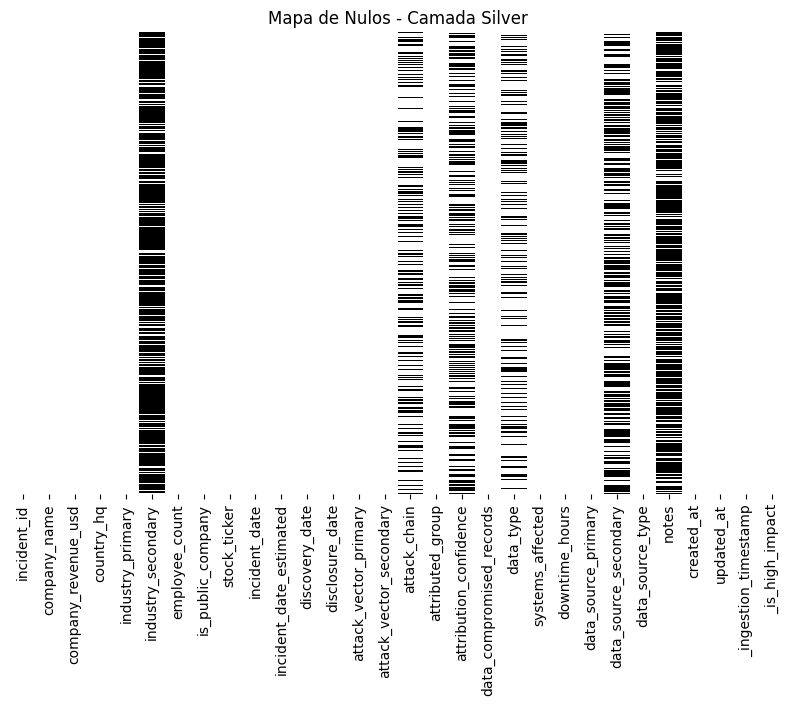

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(df_silver.isnull(), yticklabels=False, cbar=False, cmap='Greys')

plt.title('Mapa de Nulos - Camada Silver')
plt.show()

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_4092\1912410602.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')


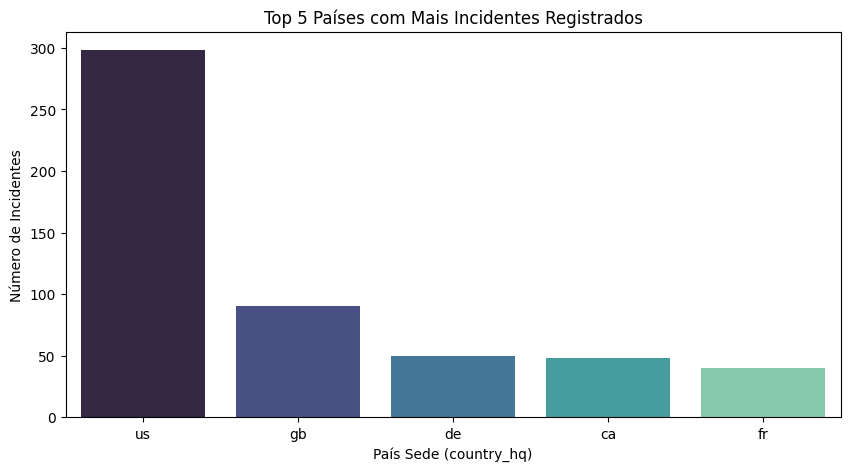

In [ ]:
plt.figure(figsize=(10, 5))

top_paises = df_silver['country_hq'].value_counts().head(5)

sns.barplot(x=top_paises.index, y=top_paises.values, palette='mako')

plt.title('Top 5 Países com Mais Incidentes Registrados')
plt.xlabel('País Sede (country_hq)')
plt.ylabel('Número de Incidentes')

plt.show()

## Análise Exploratória — Gráfico 1: Distribuição dos Vetores de Ataque por Impacto

Comparação da proporção de incidentes de alto impacto para cada tipo de vetor de ataque primário.

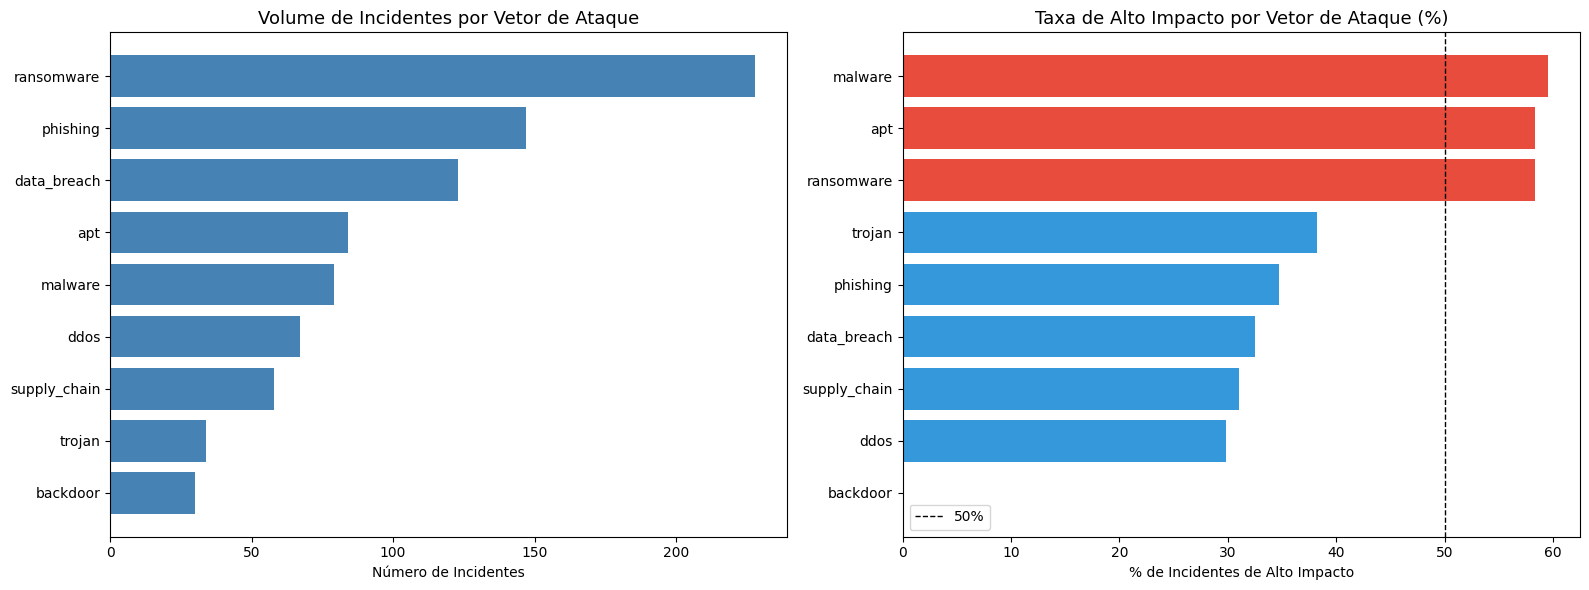

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contagem total por vetor
contagem_vetor = df_silver['attack_vector_primary'].value_counts()
axes[0].barh(contagem_vetor.index, contagem_vetor.values, color='steelblue')
axes[0].set_title('Volume de Incidentes por Vetor de Ataque', fontsize=13)
axes[0].set_xlabel('Número de Incidentes')
axes[0].invert_yaxis()

# Taxa de alto impacto por vetor
taxa_impacto = df_silver.groupby('attack_vector_primary')['_is_high_impact'].mean().sort_values(ascending=False)
cores = ['#e74c3c' if v > 0.5 else '#3498db' for v in taxa_impacto.values]
axes[1].barh(taxa_impacto.index, taxa_impacto.values * 100, color=cores)
axes[1].axvline(50, color='black', linestyle='--', linewidth=1, label='50%')
axes[1].set_title('Taxa de Alto Impacto por Vetor de Ataque (%)', fontsize=13)
axes[1].set_xlabel('% de Incidentes de Alto Impacto')
axes[1].legend()
axes[1].invert_yaxis()
plt.tight_layout()



## Análise Exploratória — Gráfico 2: Evolução Temporal dos Incidentes (2021–2025)

Série temporal mostrando o volume de incidentes por trimestre, separando alto e baixo impacto.

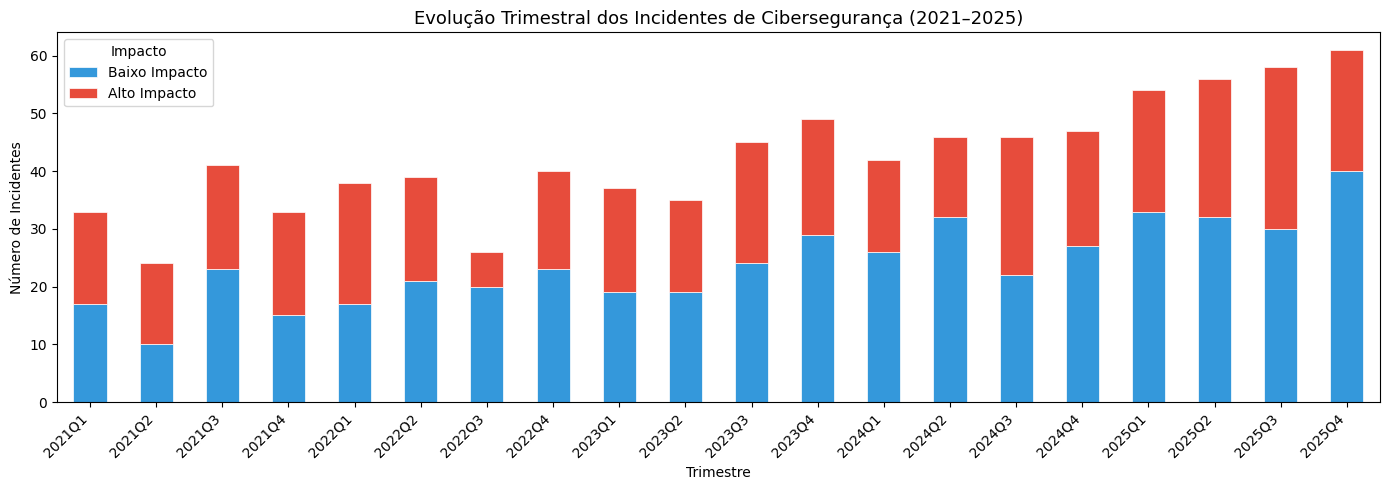

In [ ]:
df_temp = df_silver.copy()
df_temp['trimestre'] = df_temp['incident_date'].dt.to_period('Q').astype(str)

evolucao = df_temp.groupby(['trimestre', '_is_high_impact']).size().unstack(fill_value=0)
evolucao.columns = ['Baixo Impacto', 'Alto Impacto']

fig, ax = plt.subplots(figsize=(14, 5))
evolucao.plot(kind='bar', stacked=True, ax=ax,
              color=['#3498db', '#e74c3c'], edgecolor='white', linewidth=0.5)

ax.set_title('Evolução Trimestral dos Incidentes de Cibersegurança (2021–2025)', fontsize=13)
ax.set_xlabel('Trimestre')
ax.set_ylabel('Número de Incidentes')
ax.legend(title='Impacto')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()



## Análise Exploratória — Gráfico 3: Top 10 Países × Vetor de Ataque

Heatmap cruzando os 10 países com mais incidentes contra os vetores de ataque mais frequentes.

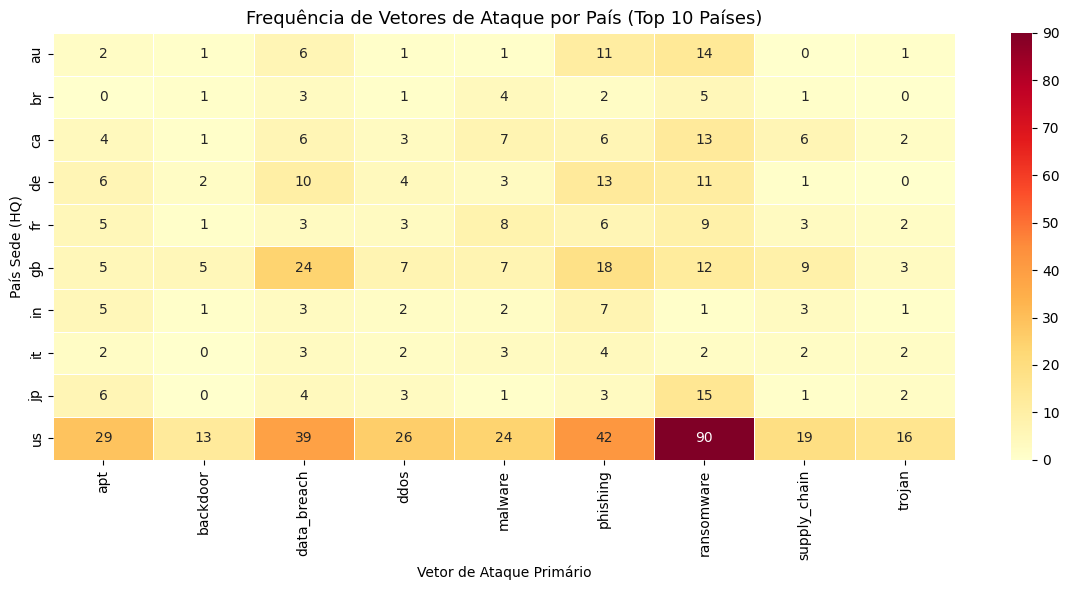

In [ ]:
top_paises = df_silver['country_hq'].value_counts().head(10).index
df_hm = df_silver[df_silver['country_hq'].isin(top_paises)]

pivot = df_hm.pivot_table(index='country_hq', columns='attack_vector_primary',
                           values='incident_id', aggfunc='count', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Frequência de Vetores de Ataque por País (Top 10 Países)', fontsize=13)
plt.xlabel('Vetor de Ataque Primário')
plt.ylabel('País Sede (HQ)')
plt.tight_layout()
plt.show()


## Data Lineage do Pipeline

Representação textual do fluxo de dados desde a origem até a camada Prata, conforme solicitado no projeto.

In [ ]:
lineage = """
╔══════════════════════════════════════════════════════════════════════════════╗
║                        DATA LINEAGE — PIPELINE MEDALION                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  [ORIGEM]                                                                    ║
║  data/incidents_master.csv                                                   ║
║  • Formato: CSV bruto                                                        ║
║                          │                                                   ║
║                          ▼                                                   ║
║  ┌─────────────────────────────────────────────────────────────────────┐     ║
║  │                     CAMADA BRONZE                                   │     ║
║  │  data/bronze/bronze.parquet                                         │     ║
║  │  Transformações:                                                    │     ║
║  │  ✔ Padronização de nomes de colunas (snake_case)                    │     ║
║  │  ✔ Conversão de tipos básicos (datas, numéricos)                    │     ║
║  │  ✔ Adição de _ingestion_timestamp                                   │     ║
║  │  ✔ Registro de metadados (hash SHA-256, tamanho, linhas)            │     ║
║  │  ✔ Relatório de qualidade gerado (nulos, duplicatas)                │     ║
║  └─────────────────────────────────────────────────────────────────────┘     ║
║                          │                                                   ║
║              ┌───────────┴─────────────┐                                    ║
║              │   VALIDAÇÕES APLICADAS  │                                    ║
║              │  • % nulos por coluna   │                                    ║
║              │  • Detecção duplicatas  │                                    ║
║              │  • Checagem de datas    │                                    ║
║              └───────────┬─────────────┘                                    ║
║                          │                                                   ║
║                          ▼                                                   ║
║  ┌─────────────────────────────────────────────────────────────────────┐     ║
║  │                     CAMADA SILVER                                   │     ║
║  │  data/silver/silver.parquet                                         │     ║
║  │  Transformações:                                                    │     ║
║  │  ✔ Remoção de duplicatas totais                                     │     ║
║  │  ✔ Conversão/validação de colunas de data                           │     ║
║  │  ✔ Padronização de categorias (lower/strip)                        │     ║
║  │  ✔ Preenchimento de nulos com valores semânticos                   │     ║
║  │  ✔ Remoção de colunas com data leakage (4 colunas)                 │     ║
║  │  ✔ Criação do label '_is_high_impact' para ML                       │     ║
║  │  Colunas removidas: quality_score, quality_grade,                   │     ║
║  │                     confidence_tier, review_flag                    │     ║
║  └─────────────────────────────────────────────────────────────────────┘     ║
║                          │                                                   ║
║                          ▼                                                   ║
║  [DESTINO FINAL]                                                             ║
║  Dataset pronto para uso em modelos de Machine Learning                      ║
║  Target: is_high_impact (classificação binária)                              ║
║  Shape final: 850 linhas × 30 colunas                                        ║
╚══════════════════════════════════════════════════════════════════════════════╝
"""
print(lineage)



╔══════════════════════════════════════════════════════════════════════════════╗
║                        DATA LINEAGE — PIPELINE MEDALION                    ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  [ORIGEM]                                                                    ║
║  data/incidents_master.csv                                                   ║
║  • Formato: CSV bruto                                                        ║
║                          │                                                   ║
║                          ▼                                                   ║
║  ┌─────────────────────────────────────────────────────────────────────┐     ║
║  │                     CAMADA BRONZE                                   │     ║
║  │  data/bronze/bronze.parquet                                         │     ║
║  │  Transformações:        